<a href="https://colab.research.google.com/github/krjohnn/LU-DM-26m/blob/main/MD2/CIFARmd2AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1,  6400] loss: 2.058
[1, 12800] loss: 1.840
[1, 19200] loss: 1.754
[1, 25600] loss: 1.705
[1, 32000] loss: 1.644
[1, 38400] loss: 1.638
[1, 44800] loss: 1.636
[2,  6400] loss: 1.560
[2, 12800] loss: 1.565
[2, 19200] loss: 1.546
[2, 25600] loss: 1.537
[2, 32000] loss: 1.516
[2, 38400] loss: 1.537
[2, 44800] loss: 1.506
[3,  6400] loss: 1.437
[3, 12800] loss: 1.461
[3, 19200] loss: 1.452
[3, 25600] loss: 1.449
[3, 32000] loss: 1.426
[3, 38400] loss: 1.441
[3, 44800] loss: 1.430
[4,  6400] loss: 1.382
[4, 12800] loss: 1.365
[4, 19200] loss: 1.386
[4, 25600] loss: 1.355
[4, 32000] loss: 1.391
[4, 38400] loss: 1.360
[4, 44800] loss: 1.379
[5,  6400] loss: 1.329
[5, 12800] loss: 1.337
[5, 19200] loss: 1.324
[5, 25600] loss: 1.299
[5, 32000] loss: 1.302
[5, 38400] loss: 1.305
[5, 44800] loss: 1.331
[6,  6400] loss: 1.266
[6, 12800] loss: 1.285
[6, 19200] loss: 1.277
[6, 25600] loss: 1.253
[6, 32000] loss: 1.274
[6, 38400] loss: 1.277
[6, 44800] loss: 1.277
[7,  6400] loss: 1.210
[7, 12800] 

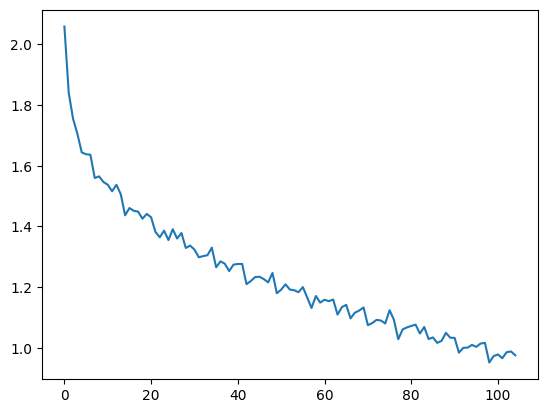

Accuracy of the network on the 10000 test images: 55 %


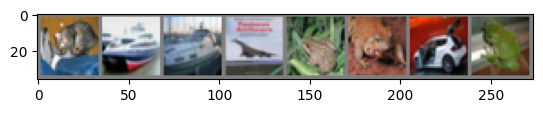

Predicted:    cat  ship plane  deer  deer  frog   car  frog
GroundTruth:    cat  ship  ship plane  frog  frog   car  frog


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(78)

# Load and Normalize the CIFAR-10 Dataset https://www.cs.toronto.edu/~kriz/cifar.html
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Define a Linear Neural Network Classifier
class Net1(nn.Module):
    def __init__(self):
        super(Net1, self).__init__()
        self.fc1 = nn.Linear(3*32*32, 10)

    def forward(self, x):
        x = x.view(-1, 3*32*32)
        x = self.fc1(x)
        return x

# Define a Non-linear Fully-Connected Neural Network with Dropout
class Net2(nn.Module):
    # (ADDED: MD2)
    def __init__(self):
        super(Net2, self).__init__()
        # First layer: 3072 in -> 512 out
        self.fc1 = nn.Linear(3*32*32, 512)
        self.dropout1 = nn.Dropout(0.1)

        # Middle layer: 512 in -> 128 out
        self.fc2 = nn.Linear(512, 128)
        self.dropout2 = nn.Dropout(0.1)

        # Final output layer: 128 in -> 10 out (for the 10 classes)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 3*32*32)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x)) # Activation function for the new middle layer
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

    # ----- Original
    # def __init__(self):
    #     super(Net2, self).__init__()
    #     self.fc1 = nn.Linear(3*32*32, 120)
    #     self.dropout = nn.Dropout(0.1)
    #     self.fc2 = nn.Linear(120, 10)

    # def forward(self, x):
    #     x = x.view(-1, 3*32*32)
    #     x = F.relu(self.fc1(x))
    #     x = self.dropout(x)
    #     x = self.fc2(x)
    #     return x

# Define a Convolutional Neural Network
class Net3(nn.Module):
    def __init__(self):
        super(Net3, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8*  8*  8, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 8*  8*  8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

model = Net2() # Try also "model = Net1()" and "model = Net3()"

criterion = nn.CrossEntropyLoss() # combines softmax layer with the cross-entropy loss function
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

loss_values = []  # List to store loss values

# Train the Network

for epoch in range(15):  # (ADDED: MD2)
# for epoch in range(2):  # loop over the dataset multiple times
    model.train() # (ADDED: MD2)
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        outputs = model(inputs)
        loss = criterion(outputs, labels) # combines softmax layer with the cross-entropy loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 100 == 99:    # print every 100 mini-batches
            print('[%d, %5d] loss: %.3f' % (epoch + 1, (i + 1) * 64, running_loss / 100))
            loss_values.append(running_loss / 100)  # Store averaged loss value
            running_loss = 0.0
    torch.save(model.state_dict(), f"checkpoint_{epoch}.pt")

print('Finished Training')

# Plot the training loss
plt.plot(loss_values, label='Training Loss')
plt.show()

# Test the Network on the Test Data
correct = 0
total = 0
model.eval() # (ADD: MD2)
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

# Show Test Images with Predictions
dataiter = iter(testloader)
images, labels = next(dataiter)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Function to Show Images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images))
print('Predicted: ', ' '.join('%5s' % classes[predicted[j]] for j in range(8)))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(8)))
